# 02 HI Genes Carry Less Total Regulatory Variance

In [37]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

def _resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/markus/in-silico-vg-analysis


In [38]:
from config import (
    GENE_PATHS,
    VARIANT_PATHS,
    SOURCE_PALETTE,
    DISPLAY_NAMES,
    DISPLAY_NAMES_SHORT,
)
from utils.plot_utils import save_plot, autosave

NOTEBOOK_NAME = 'final_figure'

print('\nDatasets:')
for name in ['clingen', 'clingen_null', 'background', 'background_null']:
    print(f'  {name}: {GENE_PATHS[name].name}')


Datasets:
  clingen: ClinGen_HI_Gnomad_genes_21022026.parquet
  clingen_null: ClinGen_HI_Synth_genes_21022026.parquet
  background: Background_Gnomad_genes_21022026.parquet
  background_null: Background_Synth_genes_21022026.parquet


In [39]:
real_gene_dfs = []
synth_gene_dfs = []

for key, path in GENE_PATHS.items():
    lf = pl.scan_parquet(path).with_columns(pl.lit(key).alias('source'))
    if 'null' in key:
        synth_gene_dfs.append(lf)
    else:
        real_gene_dfs.append(lf)

df_real = pl.concat(real_gene_dfs).collect()
df_synth = pl.concat(synth_gene_dfs).collect()

df_hi = df_real.filter(pl.col('source') == 'clingen')
df_bg = df_real.filter(pl.col('source') == 'background')
df_hi_synth = df_synth.filter(pl.col('source') == 'clingen_null')
df_bg_synth = df_synth.filter(pl.col('source') == 'background_null')

print(f'ClinGen HI: {df_hi.height} genes')
print(f'Background: {df_bg.height} genes')
print(f'ClinGen HI (Synth): {df_hi_synth.height} genes')
print(f'Background (Synth): {df_bg_synth.height} genes')

ClinGen HI: 316 genes
Background: 349 genes
ClinGen HI (Synth): 316 genes
Background (Synth): 349 genes


In [40]:
real_variant_dfs = []
synth_variant_dfs = []

for key, path in VARIANT_PATHS.items():
    lf = pl.scan_parquet(path).with_columns(pl.lit(key).alias('source'))
    if 'null' in key:
        synth_variant_dfs.append(lf)
    else:
        real_variant_dfs.append(lf)

df_real = pl.concat(real_variant_dfs).collect()
df_synth = pl.concat(synth_variant_dfs).collect()

df_hi_variants = df_real.filter(pl.col('source') == 'clingen')
df_bg_variants = df_real.filter(pl.col('source') == 'background')
df_hi_synth_variants = df_synth.filter(pl.col('source') == 'clingen_null')
df_bg_synth_variants = df_synth.filter(pl.col('source') == 'background_null')

print(f'ClinGen HI: {df_hi_variants.height} variants')
print(f'Background: {df_bg_variants.height} variants')
print(f'ClinGen HI (Synth): {df_hi_synth_variants.height} variants')
print(f'Background (Synth): {df_bg_synth_variants.height} variants')

ClinGen HI: 1743183 variants
Background: 1999142 variants
ClinGen HI (Synth): 1556962 variants
Background (Synth): 1788286 variants


# Extra paths

In [41]:
GENE_CHARACTERISTICS = "/Users/markus/in-silico-vg-analysis/07_permutations/gene_characteristics.tsv"

Mann-Whitney U: U=46490, p=4.71e-04  (ClinGen HI n=316, Background n=349)
Median Obs/Null — ClinGen HI: 4.15×   Background: 5.02×
[save_plot] Saved: final_figure_Plot1_Total_Vg_RealVsNull_14032026_1323.pdf
[save_plot] Saved: final_figure_Plot1_Total_Vg_RealVsNull_14032026_1323.svg


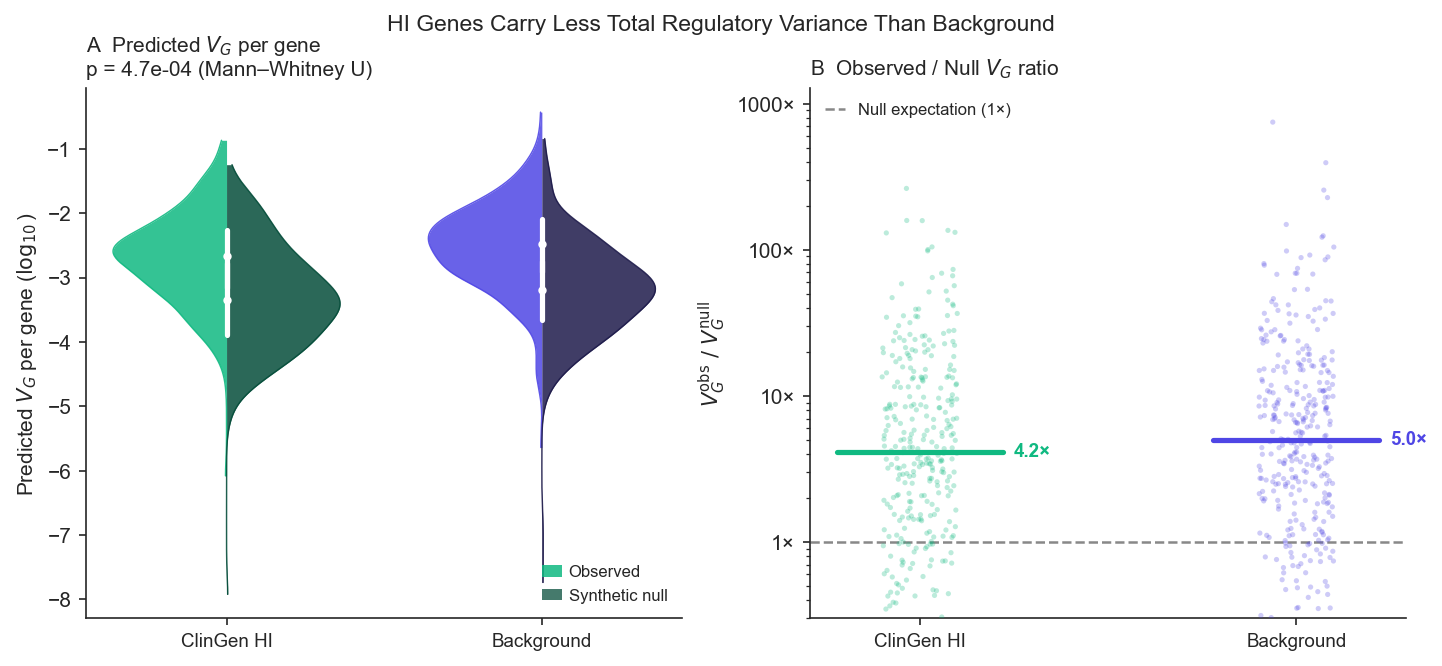

In [46]:
# ── Plot 1: Total Vg Comparison and Real-vs-Null Ratios ─────────────────────
# Part A: Split violin – Observed vs Synthetic null Vg per gene (paired by gene set)
# Part B: Obs/Null ratio per gene with log scale
# Columns: vg_predicted (real) | vg_predicted_perm (null)
# STRICTLY NOT using: vg_predicted_perm_sanity

from scipy.stats import gaussian_kde
from matplotlib.patches import Patch

# ── Data ─────────────────────────────────────────────────────────────────────
vg_hi      = df_hi['vg_predicted'].drop_nulls().to_numpy()
vg_bg      = df_bg['vg_predicted'].drop_nulls().to_numpy()
vg_hi_null = df_hi_synth['vg_predicted_perm'].drop_nulls().to_numpy()
vg_bg_null = df_bg_synth['vg_predicted_perm'].drop_nulls().to_numpy()

log_vg_hi      = np.log10(np.maximum(vg_hi, 1e-12))
log_vg_bg      = np.log10(np.maximum(vg_bg, 1e-12))
log_vg_hi_null = np.log10(np.maximum(vg_hi_null, 1e-12))
log_vg_bg_null = np.log10(np.maximum(vg_bg_null, 1e-12))

# ── Test 1: Mann-Whitney U (Observed Vg, ClinGen HI vs Background) ───────────
stat, pval = stats.mannwhitneyu(vg_hi, vg_bg, alternative='two-sided')
print(f"Mann-Whitney U: U={stat:.0f}, p={pval:.2e}  (ClinGen HI n={len(vg_hi)}, Background n={len(vg_bg)})")

# ── Test 2: Obs/Null ratio per gene ─────────────────────────────────────────
# Join real and null on gene_id; use vg_predicted_perm from null datasets only
_hi_joined = (
    df_hi.select(['gene_id', 'vg_predicted'])
    .join(df_hi_synth.select(['gene_id', 'vg_predicted_perm']), on='gene_id', how='inner')
    .filter(pl.col('vg_predicted_perm') > 0)
    .with_columns((pl.col('vg_predicted') / pl.col('vg_predicted_perm')).alias('ratio'))
)
_bg_joined = (
    df_bg.select(['gene_id', 'vg_predicted'])
    .join(df_bg_synth.select(['gene_id', 'vg_predicted_perm']), on='gene_id', how='inner')
    .filter(pl.col('vg_predicted_perm') > 0)
    .with_columns((pl.col('vg_predicted') / pl.col('vg_predicted_perm')).alias('ratio'))
)

ratio_hi = _hi_joined['ratio'].drop_nulls().to_numpy()
ratio_bg = _bg_joined['ratio'].drop_nulls().to_numpy()
median_ratio_hi = np.median(ratio_hi)
median_ratio_bg = np.median(ratio_bg)
print(f"Median Obs/Null \u2014 ClinGen HI: {median_ratio_hi:.2f}\u00d7   Background: {median_ratio_bg:.2f}\u00d7")


def _half_violin(ax, data, pos, side='right', color='blue', alpha=0.85, width=0.36):
    # Half violin via KDE with IQR box overlay
    kde = gaussian_kde(data, bw_method='scott')
    y_range = np.linspace(data.min(), data.max(), 300)
    density = kde(y_range)
    density = density / density.max() * width
    if side == 'right':
        ax.fill_betweenx(y_range, pos, pos + density, color=color, alpha=alpha, lw=0)
        ax.plot(pos + density, y_range, color=color, lw=0.7, alpha=0.9)
    else:
        ax.fill_betweenx(y_range, pos - density, pos, color=color, alpha=alpha, lw=0)
        ax.plot(pos - density, y_range, color=color, lw=0.7, alpha=0.9)
    q25, q50, q75 = np.percentile(data, [25, 50, 75])
    ax.plot([pos, pos], [q25, q75], color='white', lw=2.5, solid_capstyle='round', zorder=5)
    ax.plot(pos, q50, 'o', color='white', ms=3, zorder=6)


# ── Figure ───────────────────────────────────────────────────────────────────
with autosave('Plot1_Total_Vg_RealVsNull', notebook=NOTEBOOK_NAME):
    with sns.axes_style('ticks'):
        fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2), constrained_layout=True)

        # ── Part A: Split violin – Observed (left half) vs Synthetic null (right half) ──
        ax = axes[0]
        # ClinGen HI group at x=0
        _half_violin(ax, log_vg_hi,      pos=0, side='left',  color=SOURCE_PALETTE['clingen']   )
        _half_violin(ax, log_vg_hi_null, pos=0, side='right', color=SOURCE_PALETTE['clingen_null'])
        # Background group at x=1
        _half_violin(ax, log_vg_bg,      pos=1, side='left',  color=SOURCE_PALETTE['background'])
        _half_violin(ax, log_vg_bg_null, pos=1, side='right', color=SOURCE_PALETTE['background_null'])

        ax.set_xticks([0, 1])
        ax.set_xticklabels([DISPLAY_NAMES['clingen'], DISPLAY_NAMES['background']], fontsize=9)
        ax.set_xlabel('')
        ax.set_ylabel(r'Predicted $V_G$ per gene ($\log_{10}$)', fontsize=10)

        _p_txt = f'p = {pval:.1e}'
        ax.set_title(f'A  Predicted $V_G$ per gene\n{_p_txt} (Mann\u2013Whitney U)', fontsize=10, loc='left')

        legend_handles = [
            Patch(facecolor=SOURCE_PALETTE['clingen'], alpha=0.85, label='Observed', linewidth=0),
            Patch(facecolor=SOURCE_PALETTE['clingen_null'], alpha=0.75, label='Synthetic null', linewidth=0),
        ]
        ax.legend(handles=legend_handles, fontsize=8, frameon=False,
                  handlelength=1.2, handletextpad=0.4, loc='lower right')
        sns.despine(ax=ax)

        # ── Part B: Obs/Null ratio – log scale strip + median lines ───────────
        ax = axes[1]
        group_order = [DISPLAY_NAMES['clingen'], DISPLAY_NAMES['background']]
        palette_b = {
            DISPLAY_NAMES['clingen']:    SOURCE_PALETTE['clingen'],
            DISPLAY_NAMES['background']: SOURCE_PALETTE['background'],
        }

        _ratio_df = pd.DataFrame({
            'Ratio': np.concatenate([ratio_hi, ratio_bg]),
            'Group': (
                [DISPLAY_NAMES['clingen']] * len(ratio_hi) +
                [DISPLAY_NAMES['background']] * len(ratio_bg)
            ),
        })
        _ratio_df = _ratio_df[_ratio_df['Ratio'] > 0]

        sns.stripplot(
            data=_ratio_df, x='Group', y='Ratio',
            order=group_order, hue='Group', palette=palette_b, legend=False,
            size=2.5, alpha=0.28, jitter=True, ax=ax,
            linewidth=0, zorder=3,
        )

        # Median horizontal lines
        for xp, (grp, med, key) in enumerate(zip(
            group_order,
            [median_ratio_hi, median_ratio_bg],
            ['clingen', 'background'],
        )):
            ax.plot([xp - 0.22, xp + 0.22], [med, med],
                    color=SOURCE_PALETTE[key], lw=2.5, solid_capstyle='round', zorder=5)
            ax.text(xp + 0.25, med, f'{med:.1f}\u00d7',
                    ha='left', va='center', fontsize=9, fontweight='bold',
                    color=SOURCE_PALETTE[key])

        # Null reference line
        ax.axhline(1.0, color='#888888', lw=1.2, ls='--',
                   label='Null expectation (1\u00d7)', zorder=1)

        ax.set_yscale('log')
        ax.set_ylim(0.3, None)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:g}\u00d7'))

        ax.set_title(r'B  Observed / Null $V_G$ ratio', fontsize=10, loc='left')
        ax.set_xlabel('')
        ax.set_ylabel(r'$V_G^{\mathrm{obs}}\ /\ V_G^{\mathrm{null}}$', fontsize=10)
        ax.legend(fontsize=8, frameon=False, handlelength=1.2)
        ax.tick_params(axis='x', labelsize=9)
        sns.despine(ax=ax)

        fig.suptitle('HI Genes Carry Less Total Regulatory Variance Than Background',
                     fontsize=11, y=1.02)
        plt.show


Core promoter depletion vs 1.0 (ClinGen HI): W=31614, p=1.00e+00
Core promoter depletion vs 1.0 (Background): W=39719, p=1.00e+00
[save_plot] Saved: final_figure_Plot2_Spatial_Constraint_Core_Promoter_14032026_1329.pdf
[save_plot] Saved: final_figure_Plot2_Spatial_Constraint_Core_Promoter_14032026_1329.svg


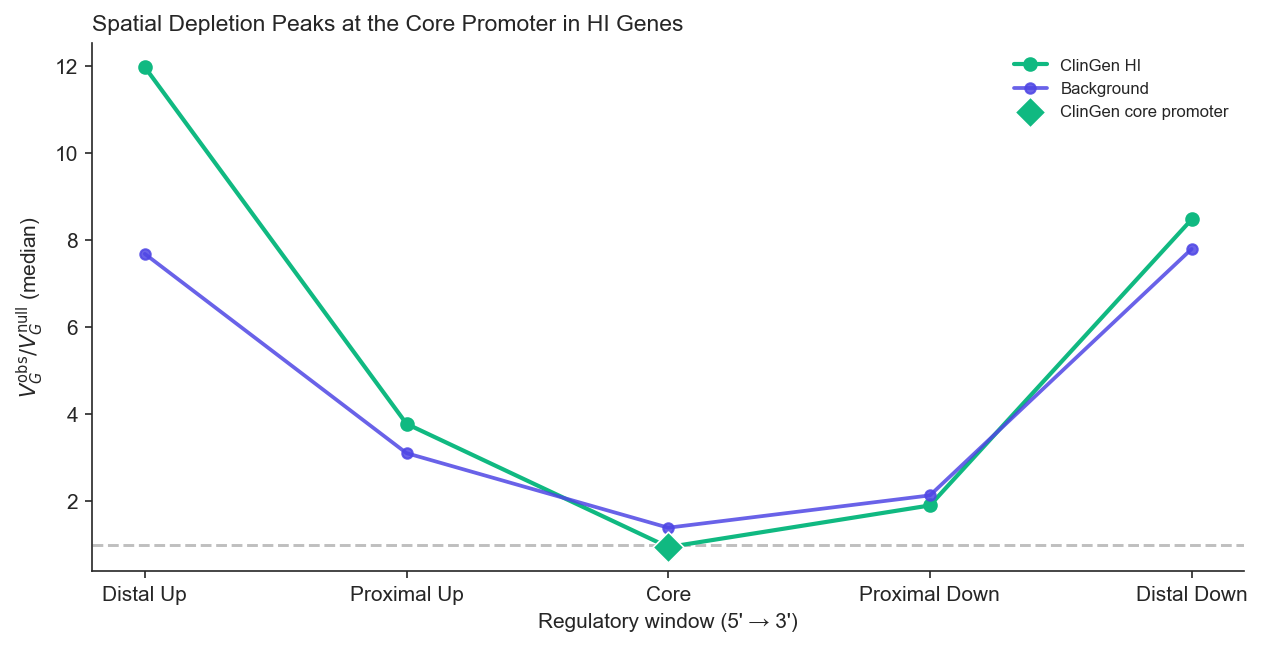

In [51]:
# ── Plot 2: Spatial Constraint in the Core Promoter ──
# Obs columns from real files are only compared to exact *_perm columns from null files.

window_cols = [
    'vg_distal_upstream',
    'vg_proximal_upstream',
    'vg_promoter_core',
    'vg_down_proximal',
    'vg_down_distal',
]
window_labels = {
    'vg_distal_upstream': 'Distal Up',
    'vg_proximal_upstream': 'Proximal Up',
    'vg_promoter_core': 'Core',
    'vg_down_proximal': 'Proximal Down',
    'vg_down_distal': 'Distal Down',
}

def _compute_window_ratios(real_df: pl.DataFrame, null_df: pl.DataFrame) -> dict[str, np.ndarray]:
    joined = real_df.select(['gene_id', *window_cols]).join(
        null_df.select(['gene_id', *[f'{w}_perm' for w in window_cols]]),
        on='gene_id',
        how='inner',
    )
    ratio_map = {}
    for w in window_cols:
        ratio_arr = (
            joined
            .filter(pl.col(f'{w}_perm') > 0)
            .select((pl.col(w) / pl.col(f'{w}_perm')).alias('ratio'))['ratio']
            .drop_nulls()
            .to_numpy()
        )
        ratio_map[w] = ratio_arr
    return ratio_map

ratios_hi = _compute_window_ratios(df_hi, df_hi_synth)
ratios_bg = _compute_window_ratios(df_bg, df_bg_synth)

summary_rows = []
for w in window_cols:
    summary_rows.append({'group': 'clingen', 'window': w, 'median_ratio': float(np.median(ratios_hi[w]))})
    summary_rows.append({'group': 'background', 'window': w, 'median_ratio': float(np.median(ratios_bg[w]))})
summary_df = pd.DataFrame(summary_rows)

core_hi = ratios_hi['vg_promoter_core']
core_bg = ratios_bg['vg_promoter_core']
core_hi_stat, core_hi_p = stats.wilcoxon(core_hi - 1.0, alternative='less')
core_bg_stat, core_bg_p = stats.wilcoxon(core_bg - 1.0, alternative='less')
print(f"Core promoter depletion vs 1.0 (ClinGen HI): W={core_hi_stat:.0f}, p={core_hi_p:.2e}")
print(f"Core promoter depletion vs 1.0 (Background): W={core_bg_stat:.0f}, p={core_bg_p:.2e}")

x = np.arange(len(window_cols))
y_hi = [summary_df.query("group == 'clingen' and window == @w")['median_ratio'].iloc[0] for w in window_cols]
y_bg = [summary_df.query("group == 'background' and window == @w")['median_ratio'].iloc[0] for w in window_cols]

with autosave('Plot2_Spatial_Constraint_Core_Promoter', notebook=NOTEBOOK_NAME, formats=('pdf', 'svg')):
    with sns.axes_style('ticks'):
        fig, ax = plt.subplots(figsize=(8.3, 4.2), constrained_layout=True)

        ax.plot(x, y_hi, '-o', color=SOURCE_PALETTE['clingen'], lw=2.0, ms=6, label=DISPLAY_NAMES['clingen'])
        ax.plot(x, y_bg, '-o', color=SOURCE_PALETTE['background'], lw=1.8, ms=5, alpha=0.85, label=DISPLAY_NAMES['background'])

        core_idx = window_cols.index('vg_promoter_core')
        ax.scatter(
            [core_idx], [y_hi[core_idx]],
            marker='D', s=110, zorder=5,
            color=SOURCE_PALETTE['clingen'], edgecolor='white', linewidth=0.8,
            label='ClinGen core promoter',
        )

        ax.axhline(1.0, color='gray', ls='--', lw=1.4, alpha=0.5, zorder=1)
        ax.set_xticks(x)
        ax.set_xticklabels([window_labels[w] for w in window_cols], rotation=0)
        ax.set_ylabel('$V_G^{\\mathrm{obs}} / V_G^{\\mathrm{null}}$ (median)')
        ax.set_xlabel('Regulatory window (5\' → 3\')')
        ax.set_title('Spatial Depletion Peaks at the Core Promoter in HI Genes', loc='left', fontsize=11)
        ax.legend(frameon=False, fontsize=8)
        sns.despine(ax=ax)
